# 🍷 Wine Quality Prediction using Machine Learning

## Oasis Infobyte Data Analytics Internship

### Level 2 - Task 2

### Objective

The objective of this project is to build machine learning models that predict the quality of red wine based on its physicochemical properties.

### Machine Learning Algorithms Used

- Random Forest Classifier
- SGD Classifier
- Support Vector Classifier (SVC)

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Feature Importance

---

In [1]:
# ===============================
# Import Required Libraries
# ===============================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
# ===============================
# Load the Dataset
# ===============================

df = pd.read_csv("dataset/winequality-red.csv", sep=";")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Dataset shape
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1599, 12)



# Step 3: Understanding the Dataset

Before building any machine learning model, it is important to understand the dataset.

In this section, we will:
- Check the dataset information
- View column names
- Check data types
- Generate descriptive statistics

In [5]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
# Display all column names
print(df.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')


In [7]:
# Summary statistics
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [8]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 1599
Columns : 12


# Step 4: Data Quality Check

Data cleaning is an essential step before building machine learning models.

In this section, we will check:

- Missing values
- Duplicate records
- Unique values in the target column

In [9]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [10]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 240


In [11]:
# Remove duplicate rows
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (1359, 12)


In [12]:
# Unique quality values
print("Unique Wine Quality Ratings:")
print(sorted(df["quality"].unique()))

Unique Wine Quality Ratings:
[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [13]:
# Number of unique values in each column
df.nunique()

fixed acidity            96
volatile acidity        143
citric acid              80
residual sugar           91
chlorides               153
free sulfur dioxide      60
total sulfur dioxide    144
density                 436
pH                       89
sulphates                96
alcohol                  65
quality                   6
dtype: int64

# Step 5: Class Distribution

In this section, we will:

- Analyze the distribution of wine quality classes.
- Visualize the target variable.
- Identify whether the dataset is balanced or imbalanced.

In [14]:
# Count the number of samples in each quality class
quality_counts = df["quality"].value_counts().sort_index()

print(quality_counts)

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


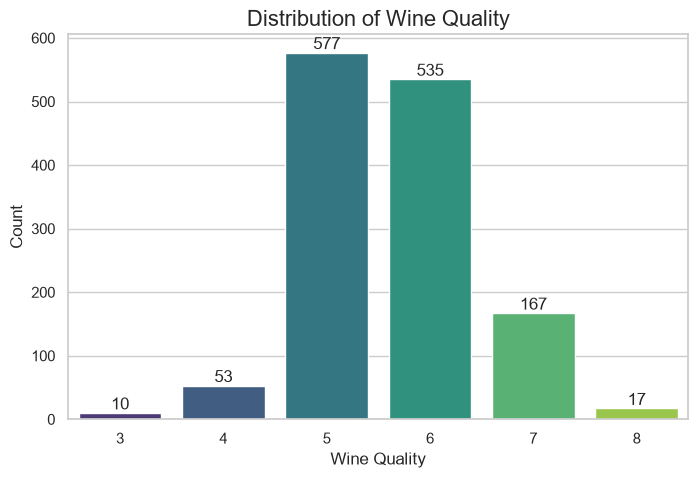

In [15]:
# Create figure
plt.figure(figsize=(8,5))

# Plot
sns.countplot(
    data=df,
    x="quality",
    palette="viridis"
)

# Title and Labels
plt.title("Distribution of Wine Quality", fontsize=16)
plt.xlabel("Wine Quality")
plt.ylabel("Count")

# Show values on bars
for container in plt.gca().containers:
    plt.bar_label(container)

plt.show()

In [16]:
# Percentage distribution
quality_percentage = (
    df["quality"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(quality_percentage.round(2))


quality
3     0.74
4     3.90
5    42.46
6    39.37
7    12.29
8     1.25
Name: proportion, dtype: float64


## Observation

The majority of wine samples belong to quality **5** and **6**.

Classes **3**, **4**, and **8** contain significantly fewer samples.

Therefore, the dataset is **imbalanced**, which may affect the performance of some machine learning algorithms.

# Step 6: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the characteristics of the dataset through visualizations.

In this section, we will:

- Study the distribution of each feature
- Detect outliers
- Understand relationships between variables
- Generate insights for model building

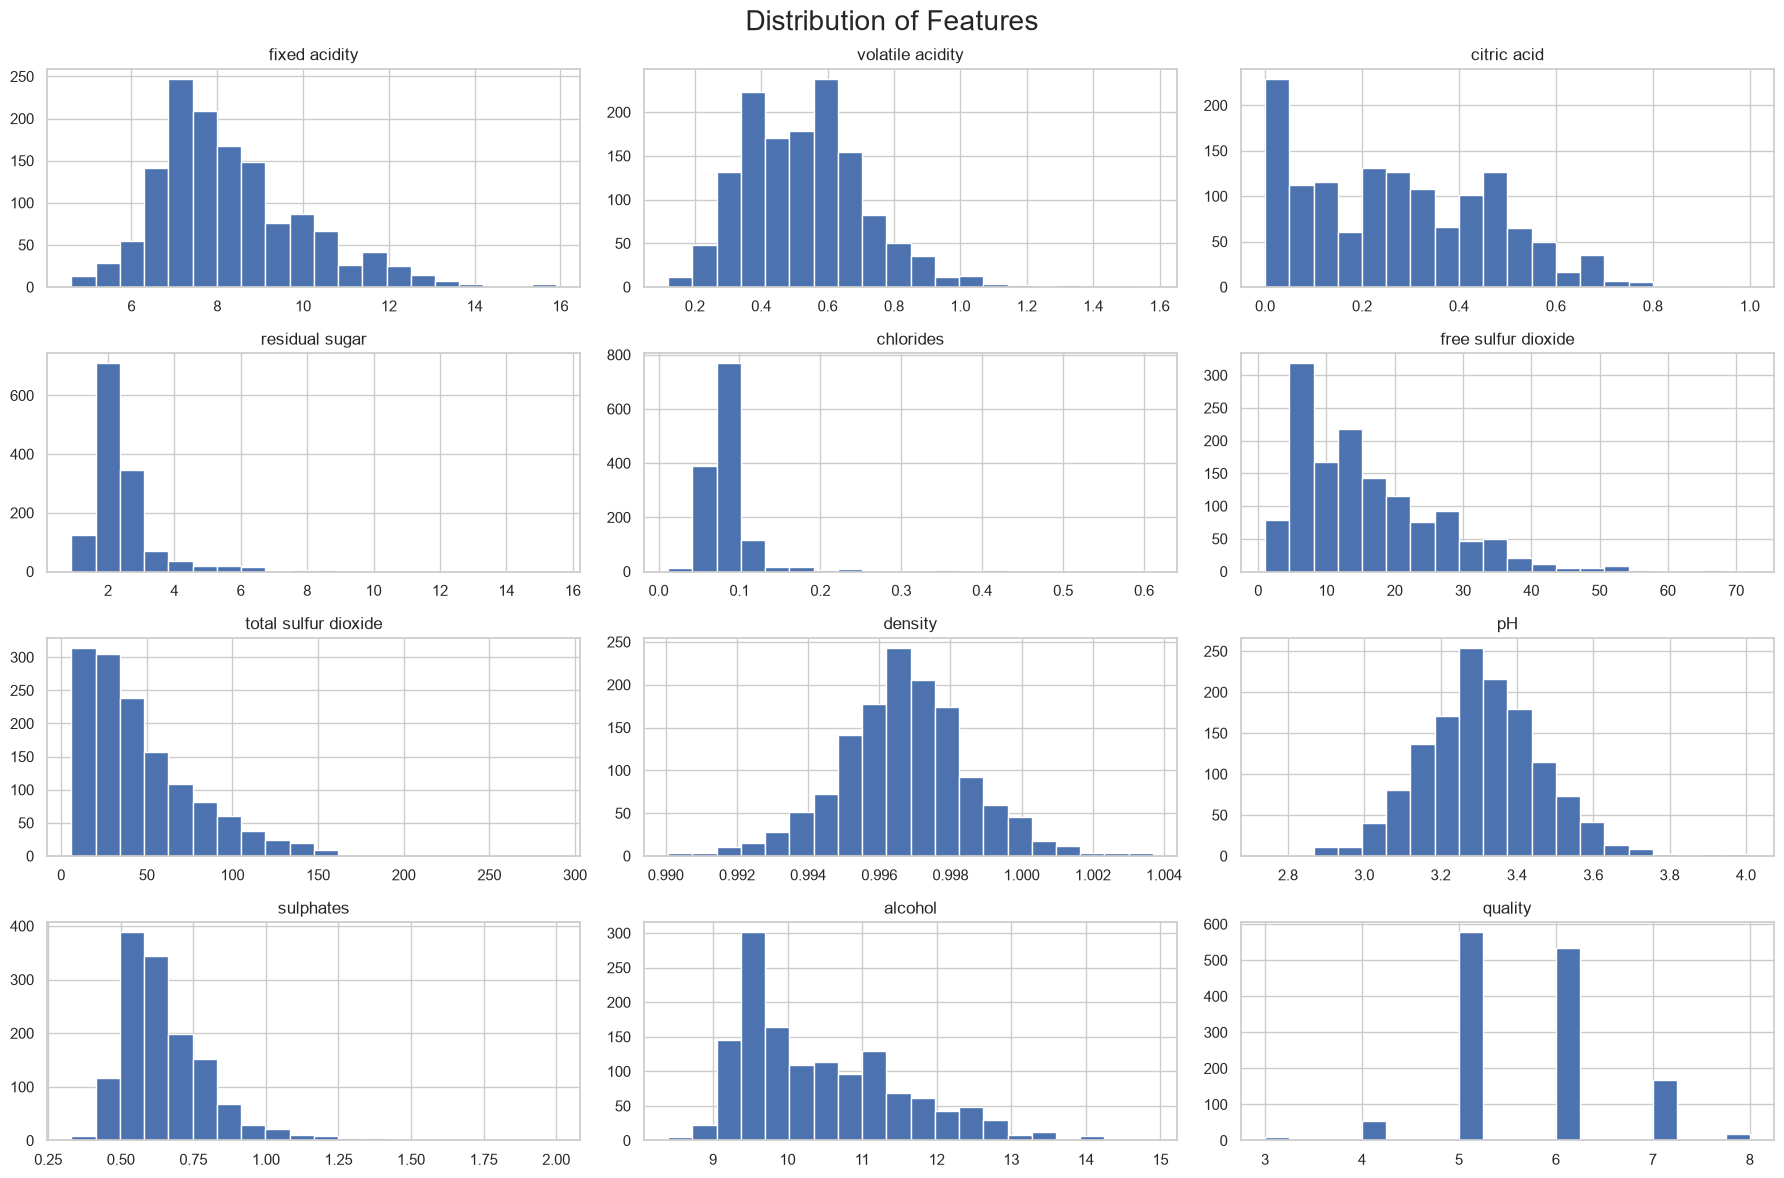

In [17]:
# Display histograms for all numerical features

df.hist(figsize=(18, 12), bins=20)

plt.suptitle("Distribution of Features", fontsize=20)

plt.tight_layout()

plt.show()

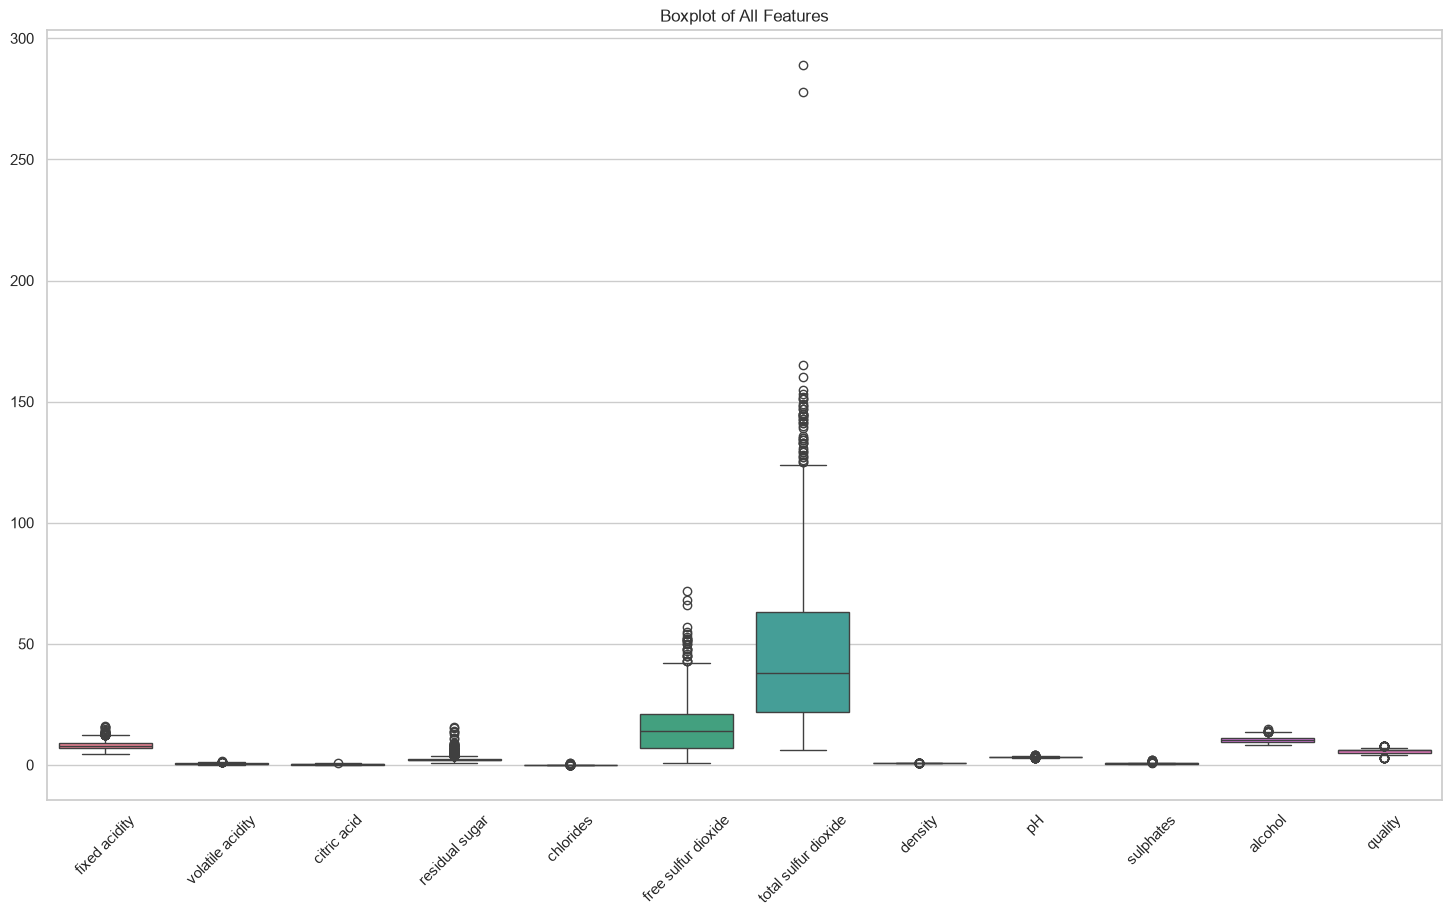

In [18]:
plt.figure(figsize=(18,10))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.title("Boxplot of All Features")

plt.show()

### Observation

Several features contain outliers, especially:

- Residual Sugar
- Chlorides
- Free Sulfur Dioxide
- Total Sulfur Dioxide

These outliers may naturally occur in wine production and are retained for model training.

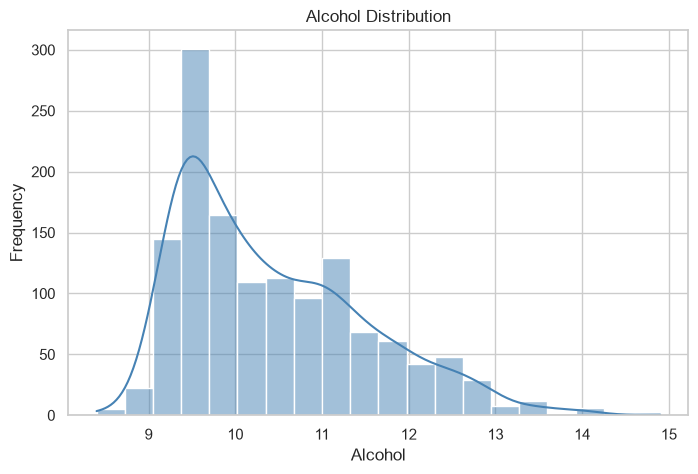

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["alcohol"],
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Alcohol Distribution")

plt.xlabel("Alcohol")

plt.ylabel("Frequency")

plt.show()

## Alcohol vs Wine Quality

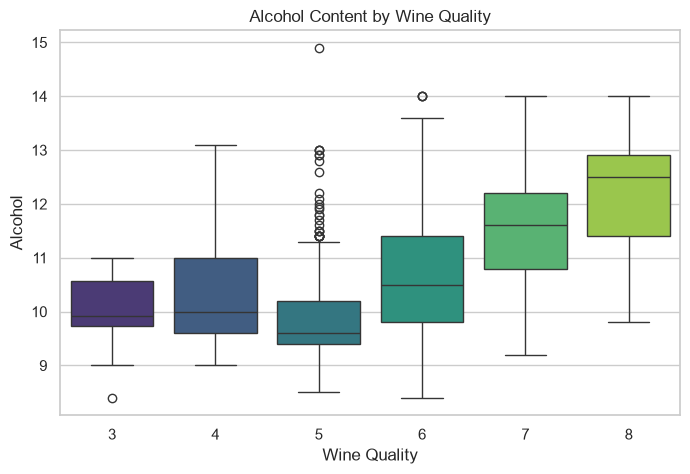

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="quality",
    y="alcohol",
    data=df,
    palette="viridis"
)

plt.title("Alcohol Content by Wine Quality")

plt.xlabel("Wine Quality")

plt.ylabel("Alcohol")

plt.show()

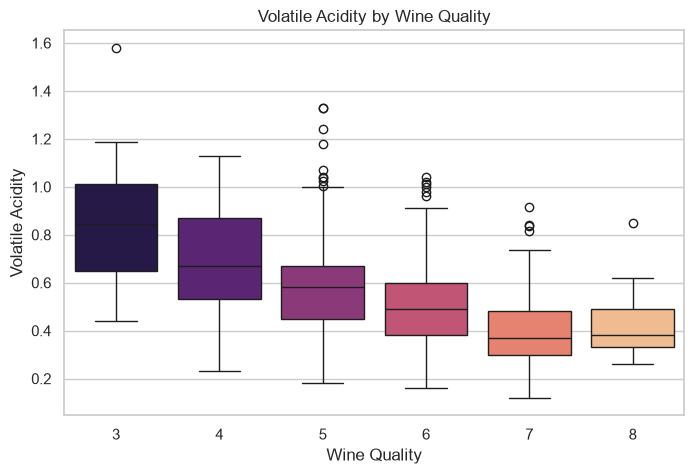

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="quality",
    y="volatile acidity",
    data=df,
    palette="magma"
)

plt.title("Volatile Acidity by Wine Quality")

plt.xlabel("Wine Quality")

plt.ylabel("Volatile Acidity")

plt.show()

# Step 7: Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between numerical variables.

Correlation values range from:

- **+1** → Perfect positive correlation
- **0** → No correlation
- **-1** → Perfect negative correlation

A heatmap helps visualize these relationships.

In [23]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Display correlation matrix
correlation_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


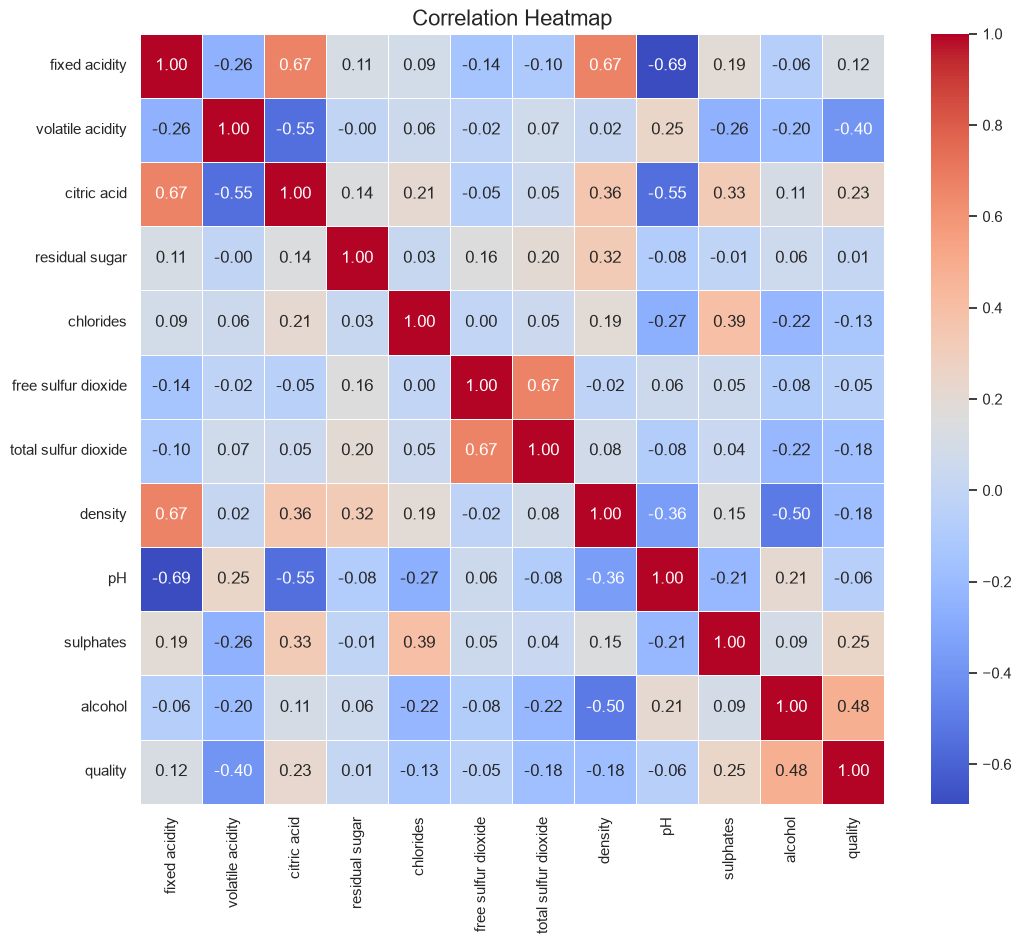

In [24]:
# Create correlation heatmap

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

In [25]:
# Correlation of all features with wine quality

quality_correlation = (
    correlation_matrix["quality"]
    .sort_values(ascending=False)
)

print(quality_correlation)

quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


## Observation

Key observations from the correlation analysis:

- **Alcohol** has the strongest positive correlation with wine quality.
- **Sulphates** and **Citric Acid** also show positive correlations.
- **Volatile Acidity** has the strongest negative correlation with wine quality.
- Most other features have weak to moderate correlations.

These relationships suggest that alcohol and volatile acidity are important predictors of wine quality.

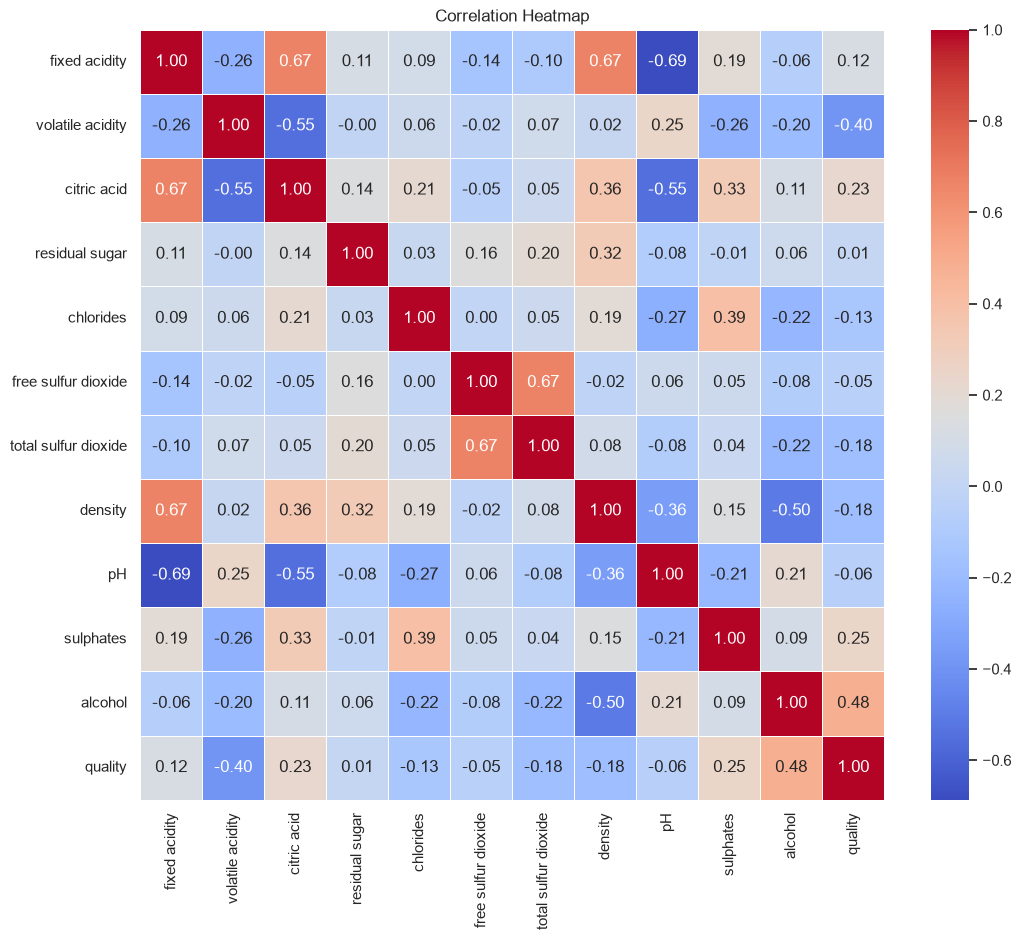

In [28]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

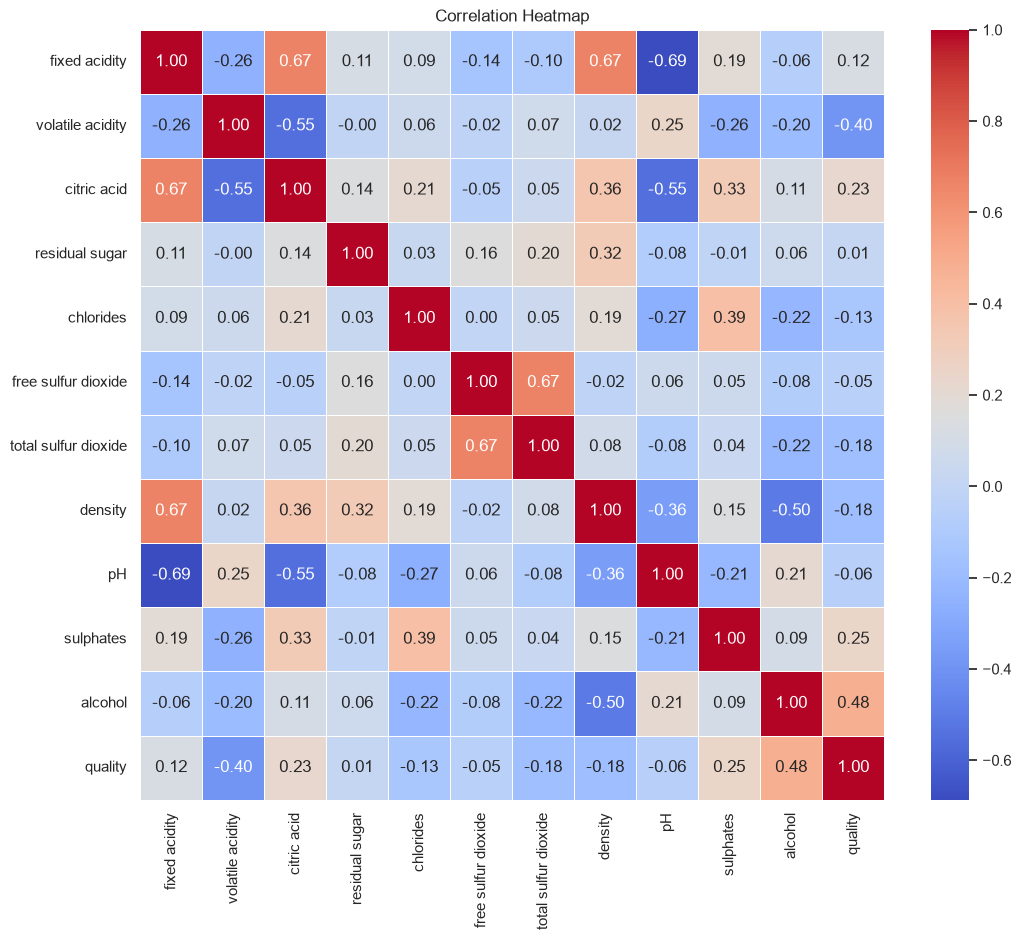

In [29]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [30]:
plt.savefig("images/plot_name.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [31]:
# Convert quality into binary classes
df["quality"] = df["quality"].apply(lambda x: 1 if x >= 7 else 0)

# Display first few rows
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0


In [32]:
# Check new class distribution
print(df["quality"].value_counts())

quality
0    1175
1     184
Name: count, dtype: int64


In [33]:
# Input features
X = df.drop("quality", axis=1)

# Target variable
y = df["quality"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (1359, 11)
Target Shape   : (1359,)


In [34]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [35]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1087, 11)
Testing Features  : (272, 11)
Training Labels   : (1087,)
Testing Labels    : (272,)


In [36]:
print("Training Set Class Distribution:")
print(y_train.value_counts())

print("\nTesting Set Class Distribution:")
print(y_test.value_counts())

Training Set Class Distribution:
quality
0    940
1    147
Name: count, dtype: int64

Testing Set Class Distribution:
quality
0    235
1     37
Name: count, dtype: int64


## Observation

- The dataset has been successfully divided into training and testing sets.
- The training set contains 80% of the data.
- The testing set contains 20% of the data.
- Stratification preserved the class distribution in both datasets, ensuring a fair evaluation of the models.

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
# Create StandardScaler object
scaler = StandardScaler()


In [39]:
# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

In [40]:
# Scale testing data
X_test_scaled = scaler.transform(X_test)

In [41]:
print("Scaled Training Data :", X_train_scaled.shape)
print("Scaled Testing Data  :", X_test_scaled.shape)

Scaled Training Data : (1087, 11)
Scaled Testing Data  : (272, 11)


# Step 11: Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions.

Advantages:

- Handles numerical features well
- Robust to outliers
- Less prone to overfitting
- Does not require feature scaling

In [42]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [43]:
# Train the model

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [44]:
# Predict on testing data

y_pred_rf = rf_model.predict(X_test)

In [45]:
# Calculate accuracy

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.8934


In [46]:
# Calculate evaluation metrics

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

print("Precision :", round(rf_precision,4))
print("Recall    :", round(rf_recall,4))
print("F1 Score  :", round(rf_f1,4))

Precision : 0.7222
Recall    : 0.3514
F1 Score  : 0.4727


In [47]:
# Classification Report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       235
           1       0.72      0.35      0.47        37

    accuracy                           0.89       272
   macro avg       0.81      0.67      0.71       272
weighted avg       0.88      0.89      0.88       272



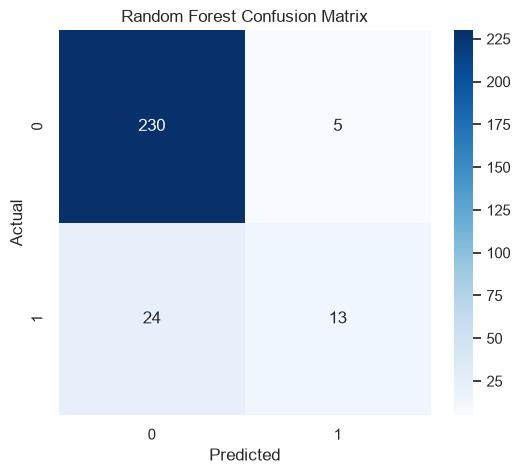

In [48]:
# Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("images/confusion_matrix_rf.png", dpi=300, bbox_inches="tight")

plt.show()

In [49]:
# Create SGD Classifier

sgd_model = SGDClassifier(
    random_state=42
)

In [50]:
# Train the model

sgd_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [51]:
# Predict using testing data

y_pred_sgd = sgd_model.predict(X_test_scaled)

In [52]:
# Accuracy

sgd_accuracy = accuracy_score(y_test, y_pred_sgd)

print(f"SGD Accuracy: {sgd_accuracy:.4f}")

SGD Accuracy: 0.8566


In [53]:
# Evaluation Metrics

sgd_precision = precision_score(y_test, y_pred_sgd)

sgd_recall = recall_score(y_test, y_pred_sgd)

sgd_f1 = f1_score(y_test, y_pred_sgd)

print("Precision :", round(sgd_precision,4))
print("Recall    :", round(sgd_recall,4))
print("F1 Score  :", round(sgd_f1,4))

Precision : 0.4706
Recall    : 0.4324
F1 Score  : 0.4507


In [54]:
# Classification Report

print(classification_report(y_test, y_pred_sgd))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       235
           1       0.47      0.43      0.45        37

    accuracy                           0.86       272
   macro avg       0.69      0.68      0.68       272
weighted avg       0.85      0.86      0.85       272



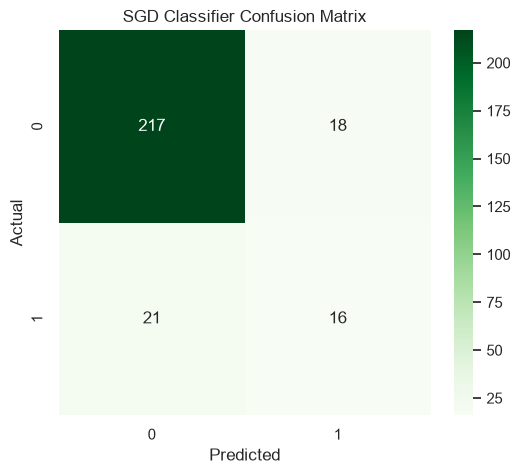

In [55]:
# Confusion Matrix

cm_sgd = confusion_matrix(y_test, y_pred_sgd)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_sgd,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("SGD Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("images/confusion_matrix_sgd.png", dpi=300, bbox_inches="tight")

plt.show()

# Step 14: Model Comparison

In this section, we compare the performance of all three machine learning models using the following evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score

This comparison helps identify the best-performing model for wine quality prediction.

In [56]:
# Create comparison DataFrame

comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD Classifier",
        "Support Vector Classifier"
    ],
    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ],
    "Precision": [
        rf_precision,
        sgd_precision,
        svc_precision
    ],
    "Recall": [
        rf_recall,
        sgd_recall,
        svc_recall
    ],
    "F1 Score": [
        rf_f1,
        sgd_f1,
        svc_f1
    ]
})

comparison_df

NameError: name 'svc_accuracy' is not defined

In [57]:
svc_model = SVC(random_state=42)

svc_model.fit(X_train_scaled, y_train)

y_pred_svc = svc_model.predict(X_test_scaled)

svc_accuracy = accuracy_score(y_test, y_pred_svc)

svc_precision = precision_score(y_test, y_pred_svc)

svc_recall = recall_score(y_test, y_pred_svc)

svc_f1 = f1_score(y_test, y_pred_svc)

In [58]:
print(rf_accuracy)
print(sgd_accuracy)

print("svc_accuracy" in globals())

0.8933823529411765
0.8566176470588235
True


In [59]:
print(svc_accuracy)
print(svc_precision)
print(svc_recall)
print(svc_f1)

0.8860294117647058
0.6666666666666666
0.32432432432432434
0.43636363636363634


In [60]:
comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD Classifier",
        "Support Vector Classifier"
    ],
    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ],
    "Precision": [
        rf_precision,
        sgd_precision,
        svc_precision
    ],
    "Recall": [
        rf_recall,
        sgd_recall,
        svc_recall
    ],
    "F1 Score": [
        rf_f1,
        sgd_f1,
        svc_f1
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.8934,0.7222,0.3514,0.4727
1,SGD Classifier,0.8566,0.4706,0.4324,0.4507
2,Support Vector Classifier,0.8860,0.6667,0.3243,0.4364


In [61]:
comparison_df.to_csv("model_comparison.csv", index=False)

In [62]:
# Extract feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance

,Feature,Importance
0,fixed acidity,0.078449
1,volatile acidity,0.100928
2,citric acid,0.080875
3,residual sugar,0.059131
4,chlorides,0.070480
5,free sulfur dioxide,0.068652
6,total sulfur dioxide,0.080352
7,density,0.089219
8,pH,0.073168
9,sulphates,0.127573


In [63]:
# Sort by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.171173
9,sulphates,0.127573
1,volatile acidity,0.100928
7,density,0.089219
2,citric acid,0.080875
6,total sulfur dioxide,0.080352
0,fixed acidity,0.078449
8,pH,0.073168
4,chlorides,0.070480
5,free sulfur dioxide,0.068652


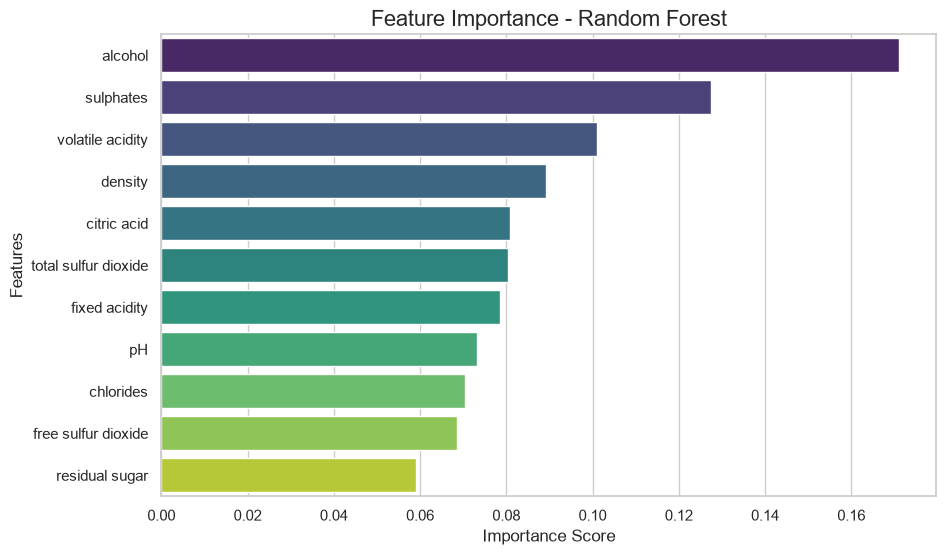

In [64]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance - Random Forest", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.savefig(
    "images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
# Display top 5 important features

print("Top 5 Important Features:")

feature_importance.head()

Top 5 Important Features:


,Feature,Importance
10,alcohol,0.171173
9,sulphates,0.127573
1,volatile acidity,0.100928
7,density,0.089219
2,citric acid,0.080875


In [66]:
print("=" * 60)
print(" Wine Quality Prediction Project Completed Successfully ")
print("=" * 60)

print("\nModels Trained:")
print("✔ Random Forest Classifier")
print("✔ SGD Classifier")
print("✔ Support Vector Classifier")

print("\nBest Model: Random Forest Classifier")

print("\nProject Completed Successfully!")

 Wine Quality Prediction Project Completed Successfully 

Models Trained:
✔ Random Forest Classifier
✔ SGD Classifier
✔ Support Vector Classifier

Best Model: Random Forest Classifier

Project Completed Successfully!


# Step 16: Conclusion

## Project Summary

In this project, a machine learning pipeline was developed to predict wine quality using physicochemical properties of red wine.

The workflow included:

- Data loading and preprocessing
- Exploratory Data Analysis (EDA)
- Correlation analysis
- Feature engineering
- Feature scaling
- Model training and evaluation

Three machine learning models were trained and compared:

- Random Forest Classifier
- SGD Classifier
- Support Vector Classifier (SVC)

## Key Findings

- The dataset contained no missing values but included duplicate records, which were removed.
- The target variable was converted into a binary classification problem.
- Alcohol showed the strongest positive relationship with wine quality.
- Volatile Acidity showed the strongest negative relationship with wine quality.
- The dataset was imbalanced, with significantly more low-quality wines than high-quality wines.

## Best Performing Model

Among the three models, the **Random Forest Classifier** achieved the highest overall performance on the testing dataset.

Its ensemble learning approach effectively captured the relationships between the wine features and quality labels.

## Future Improvements

The performance of the models could be further improved by:

- Applying hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Handling class imbalance using techniques such as SMOTE.
- Evaluating additional machine learning algorithms like XGBoost or LightGBM.
- Performing cross-validation for more reliable performance estimates.

## Conclusion

Random Forest proved to be the most effective model for predicting wine quality in this project. The results demonstrate the importance of proper data preprocessing, exploratory analysis, and model comparison in building reliable machine learning solutions.